In [115]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [116]:
df = pd.read_csv(r"C:\Users\dell\Downloads\Sales_transactions_2022_2025.csv")
df.head(3)

,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
0,T02016694,O0116694,C01482,Sophia Smith,28.0,Male,Consumer,2022-10-06,11:30:55,Online,...,Completed,Standard,4.0,No,NaN,James Anderson,SAVE10,4.0,81.0,2022
1,T02016374,O0108187,C01591,Hannah King,46.0,Female,Consumer,2024-06-03,17:06:29,Online,...,Completed,Standard,6.0,No,NaN,Ella Lewis,NaN,5.0,123.0,2024
2,T02004099,O0104099,C04140,Emma Wilson,42.0,Male,Consumer,2024-12-19,08:22:11,Online,...,Shipped,Standard,4.0,No,NaN,Liam Davis,NaN,4.0,93.0,2024


In [117]:
# 1. Be-matlab aur bohot zyada missing values wale columns drop karein
df = df.drop(columns=['Customer_Name', 'Return_Reason'])

# 2. Jin columns me 1% se kam missing values hain, unki rows drop karein
columns_with_few_nulls = [
    'Customer_Age', 
    'Customer_Gender', 
    'Product_Name', 
    'Payment_Method', 
    'Delivery_Days', 
    'Inventory_Level'
]
df = df.dropna(subset=columns_with_few_nulls)
df.info()

<class 'pandas.DataFrame'>
Index: 17035 entries, 0 to 18044
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        17035 non-null  str    
 1   Order_ID              17035 non-null  str    
 2   Customer_ID           17035 non-null  str    
 3   Customer_Age          17035 non-null  float64
 4   Customer_Gender       17035 non-null  str    
 5   Customer_Segment      17035 non-null  str    
 6   Order_Date            17035 non-null  str    
 7   Order_Time            17035 non-null  str    
 8   Sales_Channel         17035 non-null  str    
 9   Store_ID              17035 non-null  str    
 10  Store_Name            17035 non-null  str    
 11  Country               17035 non-null  str    
 12  Region                17035 non-null  str    
 13  City                  17035 non-null  str    
 14  Product_ID            17035 non-null  str    
 15  Product_Name          17035 non-nul

In [118]:
df['Promotion_Code'] = df['Promotion_Code'].fillna('NO_PROMO')
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())

In [119]:
drop_for_clustering = [
    'Transaction_ID', 
    'Order_ID', 
    'Customer_ID', 
    'Store_ID', 
    'Product_ID', 
    'Product_Name', 
    'Store_Name', 
    'Sales_Representative', 
    'Order_Date', 
    'Order_Time', 
    'City'
]

df_cluster = df.drop(columns=drop_for_clustering)

In [120]:
df.head()

,Transaction_ID,Order_ID,Customer_ID,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,Store_ID,...,Payment_Method,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
0,T02016694,O0116694,C01482,28.0,Male,Consumer,2022-10-06,11:30:55,Online,LA-01,...,Credit Card,Completed,Standard,4.0,No,James Anderson,SAVE10,4.0,81.0,2022
1,T02016374,O0108187,C01591,46.0,Female,Consumer,2024-06-03,17:06:29,Online,SYD-01,...,Debit Card,Completed,Standard,6.0,No,Ella Lewis,NO_PROMO,5.0,123.0,2024
2,T02004099,O0104099,C04140,42.0,Male,Consumer,2024-12-19,08:22:11,Online,PAR-01,...,Credit Card,Shipped,Standard,4.0,No,Liam Davis,NO_PROMO,4.0,93.0,2024
3,T02010280,O0110280,C03663,18.0,Male,Corporate,2025-10-05,14:32:43,B2B Portal,NYC-01,...,paypal,Completed,Next Day,2.0,No,Grace Harris,HOLIDAY20,4.0,59.0,2025
4,T02012685,O0112685,C02749,37.0,Male,Returning Customer,2022-09-13,14:55:16,B2B Portal,CHI-01,...,Apple Pay,Completed,Express,2.0,No,Sophia Brown,NO_PROMO,2.0,56.0,2022


In [121]:
from sklearn.preprocessing import StandardScaler

# Customer purchasing base ke numerical columns
features = ['Customer_Age', 'Quantity', 'Sales_Amount', 'Discount_Percentage', 'Profit', 'Customer_Rating']

X = df_cluster[features]

# Distance-based algorithm ke liye scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering data ready shape:", X_scaled.shape)

Clustering data ready shape: (17035, 6)


In [122]:
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.head()

,Customer_Age,Quantity,Sales_Amount,Discount_Percentage,Profit,Customer_Rating
0,-1.016619,-0.070952,-0.346872,-0.182408,-0.270627,0.011274
1,0.659074,2.159068,-0.185424,1.270968,-0.170821,1.115055
2,0.286698,-0.070952,-0.449051,1.270968,-0.539428,0.011274
3,-1.947559,4.946593,0.724628,1.270968,0.531349,0.011274
4,-0.178772,1.044058,-0.259202,1.270968,-0.117300,-2.196288


In [123]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(X_scaled)
df_scaled.head()

,Customer_Age,Quantity,Sales_Amount,Discount_Percentage,Profit,Customer_Rating,Cluster
0,-1.016619,-0.070952,-0.346872,-0.182408,-0.270627,0.011274,0
1,0.659074,2.159068,-0.185424,1.270968,-0.170821,1.115055,1
2,0.286698,-0.070952,-0.449051,1.270968,-0.539428,0.011274,1
3,-1.947559,4.946593,0.724628,1.270968,0.531349,0.011274,1
4,-0.178772,1.044058,-0.259202,1.270968,-0.117300,-2.196288,1


In [124]:
df_scaled.shape

(17035, 7)

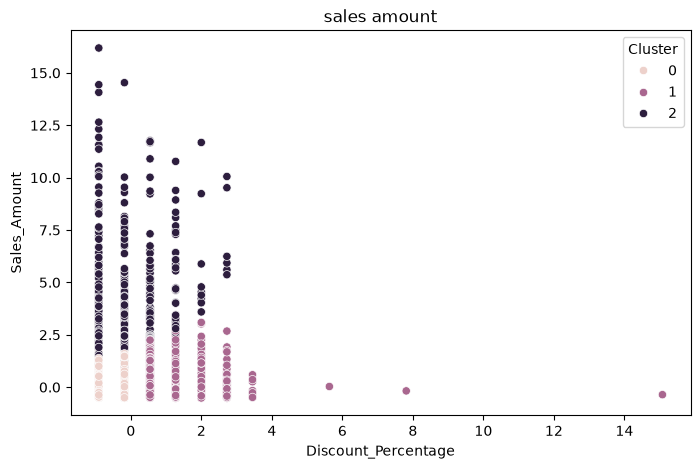

In [125]:
plt.figure(figsize=(8,5))
sns.scatterplot(x= 'Discount_Percentage',y= 'Sales_Amount',data= df_scaled, hue= 'Cluster')
plt.title('sales amount')
plt.show()

In [126]:
from sklearn.cluster import DBSCAN
db_cluster = DBSCAN(eps= 0.5,min_samples= 10)
df_scaled['db_cluster'] = db_cluster.fit_predict(df_scaled.drop(columns=['Cluster']))
df_scaled.head()

,Customer_Age,Quantity,Sales_Amount,Discount_Percentage,Profit,Customer_Rating,Cluster,db_cluster
0,-1.016619,-0.070952,-0.346872,-0.182408,-0.270627,0.011274,0,0
1,0.659074,2.159068,-0.185424,1.270968,-0.170821,1.115055,1,-1
2,0.286698,-0.070952,-0.449051,1.270968,-0.539428,0.011274,1,1
3,-1.947559,4.946593,0.724628,1.270968,0.531349,0.011274,1,-1
4,-0.178772,1.044058,-0.259202,1.270968,-0.117300,-2.196288,1,-1


In [127]:
df_scaled.db_cluster.unique()

array([ 0, -1,  1,  2,  3,  4, 10, 27,  5, 66,  6,  7, 37,  8, 81,  9, 11,
       12, 13, 14, 15, 16, 17, 18, 19, 20, 44, 21, 22, 23, 32, 24, 25, 26,
       28, 29, 30, 31, 57, 33, 34, 35, 36, 54, 39, 38, 40, 41, 42, 43, 45,
       46, 47, 69, 48, 79, 49, 50, 51, 52, 53, 55, 77, 56, 71, 68, 58, 64,
       59, 60, 61, 62, 74, 63, 70, 65, 67, 76, 72, 73, 75, 78, 82, 83, 80])

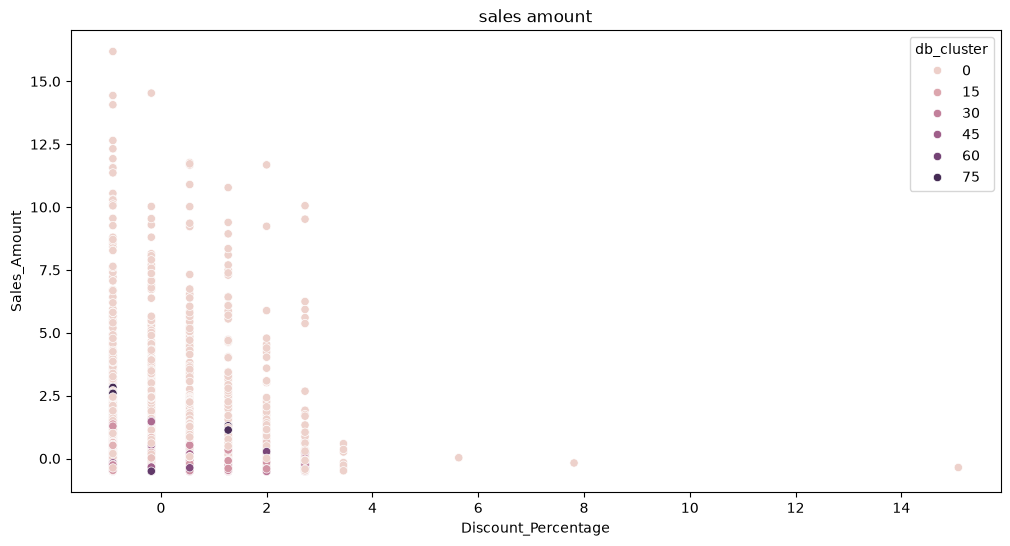

In [128]:
plt.figure(figsize=(12,6))
sns.scatterplot(x= 'Discount_Percentage',y= 'Sales_Amount',data= df_scaled, hue= 'db_cluster')
plt.title('sales amount')
plt.show()

In [129]:
y = df_scaled['Sales_Amount']
df_scaled = df_scaled.drop(columns=['Sales_Amount'])

In [131]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# X me se labels drop karein
x_label = df_scaled.drop(columns=['Cluster', 'db_cluster'])

# y me discrete classes (K-Means ke clusters: 0, 1, 2) de
y = df_scaled['Cluster']

# 3 classes ke liye maximum n_components = 2 (classes - 1)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(x_label, y)

print("X_lda shape:", X_lda.shape)

X_lda shape: (17035, 2)


In [133]:
X_lda

array([[-0.35738458, -0.44728971],
       [ 2.44023797,  0.49980814],
       [ 2.46893175, -0.4726992 ],
       ...,
       [ 1.06531422, -0.54240117],
       [-1.78557737, -0.8383475 ],
       [-1.81570431, -0.79740464]], shape=(17035, 2))

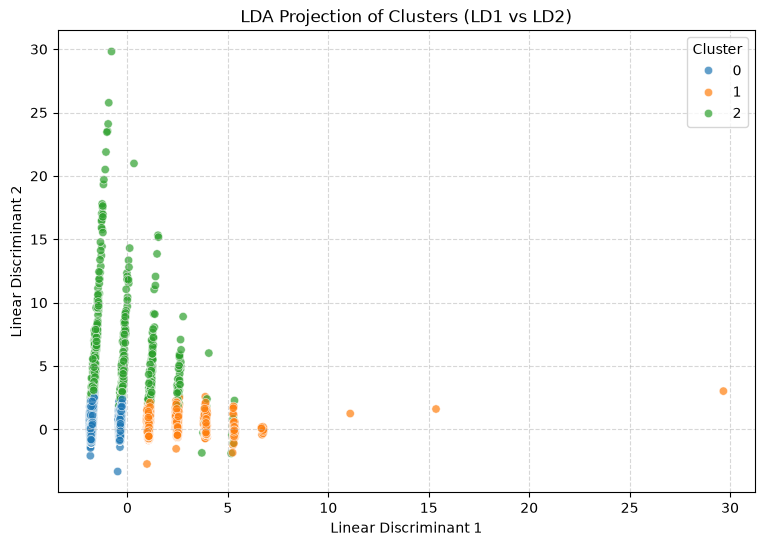

In [134]:
# 1. LDA results ka DataFrame banayein
df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['Cluster'] = y.values  # K-Means cluster labels

# 2. Scatter plot banayein
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_lda, 
    x='LD1', 
    y='LD2', 
    hue='Cluster', 
    palette='tab10', 
    alpha=0.7
)

plt.title('LDA Projection of Clusters (LD1 vs LD2)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [135]:
0.44728971 + 0.35738458

0.80467429